In [48]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/salader/dogsvscats


In [49]:
import os

for root, dirs, files in os.walk(path, topdown=True):
    print(root)
    for d in dirs:
        print("  DIR:", d)
    for f in files:
        print("  FILE:", f)
    break

/kaggle/input/datasets/salader/dogsvscats
  DIR: test
  DIR: train
  DIR: catsvsdogs


In [50]:
train_path = os.path.join(path,'/kaggle/input/datasets/salader/dogsvscats/train')
test_path = os.path.join(path,'/kaggle/input/datasets/salader/dogsvscats/test')

print(train_path)
print(test_path)

/kaggle/input/datasets/salader/dogsvscats/train
/kaggle/input/datasets/salader/dogsvscats/test


In [51]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

**GENERATORS FOR IMAGE_DATASET_FROM_DIRECTORY**

In [52]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = train_path,
    labels='inferred',
    label_mode ='int',
    color_mode = 'rgb',
    batch_size=32,
    image_size=(256,256)
)


print(train_ds.class_names)


validation_ds = keras.utils.image_dataset_from_directory(
    directory = test_path,
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
['cats', 'dogs']
Found 5000 files belonging to 2 classes.


**NORMALIZATION**

In [53]:
def image_normalize(image,label):
    image = tf.cast(image/255.,tf.float32)
    return image,label

train_ds = train_ds.map(image_normalize)
validation_ds =validation_ds.map(image_normalize)


**CREATION OF CNN MODEL**

In [54]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding = 'valid',activation = 'relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2),strides = 2, padding = 'valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding = 'valid',activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2),strides = 2, padding = 'valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding = 'valid',activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2),strides = 2, padding = 'valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation = 'sigmoid'))

In [55]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [56]:
model.compile(optimizer = 'Adam', loss= 'binary_crossentropy', metrics = ['accuracy'])

In [57]:
history = model.fit(train_ds, epochs =10, validation_data = validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.5874 - loss: 1.4557 - val_accuracy: 0.6674 - val_loss: 0.6136
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.6971 - loss: 0.5848 - val_accuracy: 0.6256 - val_loss: 0.6461
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.7586 - loss: 0.4951 - val_accuracy: 0.7882 - val_loss: 0.4755
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.8059 - loss: 0.4276 - val_accuracy: 0.8036 - val_loss: 0.4395
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.8411 - loss: 0.3590 - val_accuracy: 0.7976 - val_loss: 0.4988
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.8747 - loss: 0.2928 - val_accuracy: 0.7870 - val_loss: 0.4632
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.9163 - loss: 0.2074 - val_accuracy: 0.8198 - val_loss: 0.6073
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.9373 - loss: 0.1615 - 

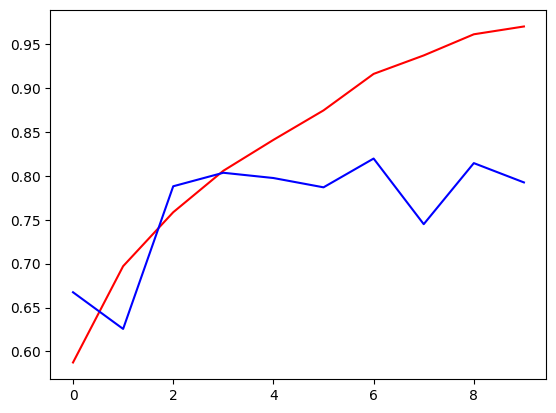

In [58]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color = 'red',label = 'train')
plt.plot(history.history['val_accuracy'],color = 'blue',label = 'validation')
plt.show()

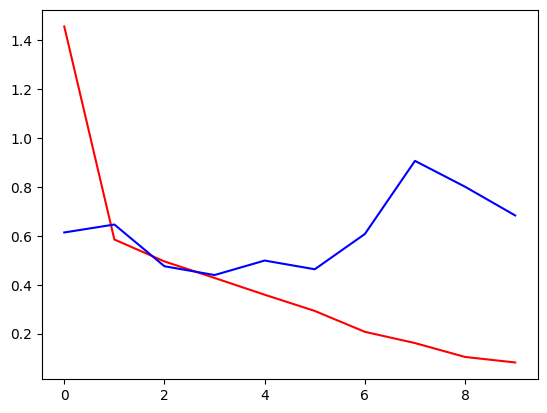

In [59]:
plt.plot(history.history['loss'],color = 'red',label = 'train')
plt.plot(history.history['val_loss'],color = 'blue',label = 'validation')
plt.show()

**time for checking**

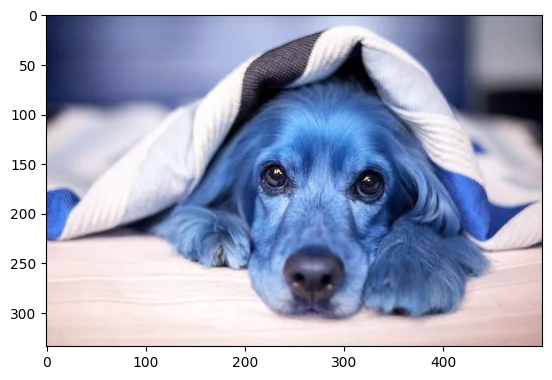

In [60]:
import cv2

cap = cv2.imread('/kaggle/input/datasets/nancy341/doggggggggggg2/dog2.webp')

plt.imshow(cap)

In [61]:
cap.shape

(334, 500, 3)

In [62]:
cap = cv2.resize(cap,(256,256))

cap2 = cap.reshape((1,256,256,3))

model.predict(cap2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step


array([[1.]], dtype=float32)